# Modelagem supervisionada — risco de não alfabetização por aluno

**Tech Challenge Fase 3 · Pós-Tech FIAP — IA para Devs**

O treinamento pesado vive em `src/models/train_aluno.py`, executável por
`bash run.sh aluno`. Este notebook **audita** esse pipeline: recarrega o artefato salvo,
reproduz a métrica do holdout num processo novo e apresenta a avaliação e a
interpretabilidade.

A separação é deliberada. Um notebook que treina não é reprodutível — depende da ordem em
que alguém executou as células. O script é a fonte da verdade; o notebook é a leitura dos
resultados. É assim que a mesma pipeline sobe para produção sem reescrita.

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, precision_recall_curve,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split

from src.config import ALVO, FEATURES, MODELS_DIR, NUM_FEATURES, REPORTS_DIR, SEED
from src.features.build_features import carrega_base, matriz_xy
from src.models.train_aluno import N_CARGA
from src.viz.plots import (
    AGUA, AZUL, LARANJA, NEUTRO, TINTA_SEC, anota, aplica_estilo,
    barras_horizontais, limpa_eixos, salva,
)

aplica_estilo()
metricas = json.loads((REPORTS_DIR / "metricas_aluno.json").read_text(encoding="utf-8"))
print("modelo escolhido:", metricas["modelo_escolhido"])

modelo escolhido: hist_gradient_boosting


## 1. O desenho anti-vazamento

Três camadas de proteção, cada uma respondendo a um modo de falha diferente:

**1. Exclusão por definição.** `alfabetizado := proficiencia >= 743`. A proficiência e todas
as médias que a resumem no mesmo ano ficam fora — não são preditores, são o resultado.

**2. Defasagem temporal.** O aluno é de 2024; todo o contexto municipal e estadual é de 2023.
Isso replica a situação real de uso: em janeiro de 2025, o gestor tem os números de 2023 e
precisa decidir onde agir antes da avaliação seguinte.

**3. Vetos por diagnóstico.** Colunas estáticas que a Fase 2 agregou sem o ano foram testadas
individualmente na EDA (seção 3.1) e vetadas quando correlacionavam mais com 2024 do que com
2023.

E, dentro do pipeline, o **cross-fitting** do `TargetEncoder`: a codificação de cada linha é
estimada em folds que não a contêm, de modo que o alvo da própria linha nunca influencia sua
própria feature.

In [2]:
modelo = joblib.load(MODELS_DIR / "pipeline_aluno.joblib")
modelo

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputacao',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median'))]),
                                                  ['peso_aluno',
                                                   'mun_ctx_taxa_alfabetizacao',
                                                   'mun_ctx_media_portugues',
                                                   'mun_meta_2024',
                                                   'mun_gap_projetado',
                                                   'uf_ctx_taxa_alfabetizacao',
                                                   'uf_ctx_media_portugues',
                                                   'uf_ctx_ranking_nacional',
                                                   'escola_n_alunos_av...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=20,
                                                                                 sparse_output=False))]),
                                                  ['rede', 'serie', 'caderno',
                                                   'regiao', 'sigla_uf']),
                                                 ('alta_card',
                                                  Pipeline(steps=[('encoder',
                                                                   TargetEncoder(random_state=42,
                                                                                 target_type='binary'))]),
                                                  ['id_municipio',
                                                   'id_escola'])])),
                ('clf',
                 HistGradientBoostingClassifier(class_weight='balanced',
                                                learning_rate=0.03,
                                                max_iter=400,
                                                random_state=42))])

In [3]:
prep = modelo.named_steps["prep"]
print("Blocos do ColumnTransformer:\n")
for nome, transformador, colunas in prep.transformers_:
    if nome == "remainder":
        continue
    passos = " -> ".join(p[0] for p in transformador.steps)
    print(f"  {nome:<10} {passos}")
    print(f"             {len(colunas)} colunas: {', '.join(map(str, colunas[:4]))}"
          f"{' ...' if len(colunas) > 4 else ''}\n")
print(f"Saída do pré-processamento: {len(prep.get_feature_names_out())} colunas")

Blocos do ColumnTransformer:

  num        imputacao
             15 colunas: peso_aluno, mun_ctx_taxa_alfabetizacao, mun_ctx_media_portugues, mun_meta_2024 ...

  cat        imputacao -> onehot
             5 colunas: rede, serie, caderno, regiao ...

  alta_card  encoder
             2 colunas: id_municipio, id_escola

Saída do pré-processamento: 82 colunas


Todo o pré-processamento está **dentro** do objeto salvo. Não existe etapa manual entre o
dado bruto e a predição: `modelo.predict_proba(X)` recebe o DataFrame com as colunas
originais e cuida de imputação, escala, one-hot e target encoding. É o que torna o artefato
implantável — e o que garante que as estatísticas de ajuste vieram só do treino.

## 2. Reprodutibilidade

O teste é simples e severo: num processo novo, refazer a carga e o split com a mesma semente,
recarregar o artefato do disco e verificar se a métrica bate com a registrada no treino.

**Este `assert` já se pagou.** Na primeira execução ele falhou, e o motivo não era óbvio: o
`USING SAMPLE ... (reservoir, seed)` do DuckDB **não é determinístico** sob leitura paralela
— duas chamadas com a mesma semente devolveram amostras com apenas 22% de sobreposição. Toda
a semeadura do scikit-learn estava correta; o que variava era *quais linhas* chegavam ao
modelo. A carga passou a usar `ORDER BY hash(id_aluno || seed) LIMIT n`, que depende só do
dado e da semente, nunca do plano de execução.

Semear o modelo não basta se a amostragem dos dados não for determinística — e sem um teste
que compare métricas entre processos, isso passa despercebido.

In [4]:
df = carrega_base(n_linhas=N_CARGA, com_proficiencia=True)
X, y = matriz_xy(df)
idx = np.arange(len(df))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, stratify=y, random_state=SEED)
X_te, y_te = X.iloc[idx_te], y[idx_te]

proba = modelo.predict_proba(X_te)[:, 1]
pr_auc = average_precision_score(y_te, proba)
roc_auc = roc_auc_score(y_te, proba)

registrado = metricas["holdout_aleatorio"]
print(f"{'':<12}{'reproduzido':>14}{'registrado':>14}{'diferença':>12}")
for nome, obtido, esperado in [("PR-AUC", pr_auc, registrado["pr_auc"]),
                               ("ROC-AUC", roc_auc, registrado["roc_auc"])]:
    print(f"{nome:<12}{obtido:>14.6f}{esperado:>14.6f}{abs(obtido - esperado):>12.2e}")

assert abs(pr_auc - registrado["pr_auc"]) < 1e-9, "o holdout nao foi reproduzido"
print("\nOK — mesma semente, mesmo split, mesmas métricas.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

15:31:13 | INFO    | base carregada: 600,000 linhas | 40.17% da classe positiva (nao alfabetizado)


               reproduzido    registrado   diferença
PR-AUC            0.589923      0.589923    0.00e+00
ROC-AUC           0.698576      0.698576    0.00e+00

OK — mesma semente, mesmo split, mesmas métricas.


## 3. Comparação de famílias

Quatro níveis de capacidade, validados por CV 3-fold sobre a mesma subamostra, com
`class_weight="balanced"` em todos — a comparação é entre famílias, não entre políticas de
desbalanceamento.

,PR-AUC (CV),desvio,tempo (s)
modelo,,,
hist_gradient_boosting,0.5652,0.0025,60.9026
lightgbm,0.5651,0.0019,40.5528
regressao_logistica,0.5632,0.0022,26.6573
baseline_maioria,0.4007,0.0000,36.3017


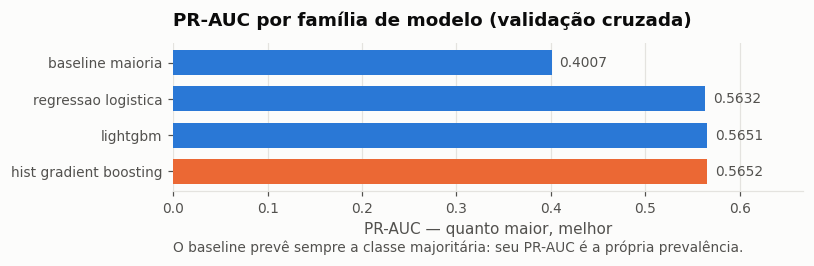

In [5]:
familias = pd.DataFrame(metricas["comparacao_familias"]).set_index("modelo")
familias = familias.rename(columns={"pr_auc_medio": "PR-AUC (CV)", "desvio": "desvio",
                                    "segundos": "tempo (s)"}).round(4)
display(familias)

fig, ax = plt.subplots(figsize=(7.5, 2.8))
ordenado = familias.sort_values("PR-AUC (CV)")
destaque = {metricas["modelo_escolhido"]: LARANJA}
barras_horizontais(ax, [i.replace("_", " ") for i in ordenado.index],
                   list(ordenado["PR-AUC (CV)"]), formato="{:.4f}",
                   destaque={k.replace("_", " "): v for k, v in destaque.items()})
ax.set_title("PR-AUC por família de modelo (validação cruzada)")
ax.set_xlabel("PR-AUC — quanto maior, melhor")
anota(ax, "O baseline prevê sempre a classe majoritária: seu PR-AUC é a própria prevalência.", y=-0.34)
fig.tight_layout()
salva(fig, "modelo_comparacao_familias.png")
plt.show()

O ganho do boosting sobre a regressão logística é de milésimos. Isso não é acaso: as
features são quase todas **agregados municipais**, cuja relação com o risco individual é
suave e praticamente monotônica. Não há interações complexas a capturar porque não há
variáveis individuais — o modelo flexível não tem o que explorar além do que a reta já pega.

É um resultado que vale reportar: **a escolha do algoritmo não é o gargalo deste problema.
Os dados disponíveis são.**

In [6]:
print("Hiperparâmetros selecionados na busca aleatória:\n")
for chave, valor in sorted(metricas["hiperparametros"].items()):
    print(f"  {chave:<22} {valor}")

Hiperparâmetros selecionados na busca aleatória:

  categorical_features   warn
  class_weight           balanced
  early_stopping         auto
  interaction_cst        None
  l2_regularization      0.0
  learning_rate          0.03
  loss                   log_loss
  max_bins               255
  max_depth              None
  max_features           1.0
  max_iter               400
  max_leaf_nodes         31
  min_samples_leaf       20
  monotonic_cst          None
  n_iter_no_change       10
  random_state           42
  scoring                loss
  tol                    1e-07
  validation_fraction    0.1
  verbose                0
  warm_start             False


## 4. Avaliação

### 4.1 Curvas

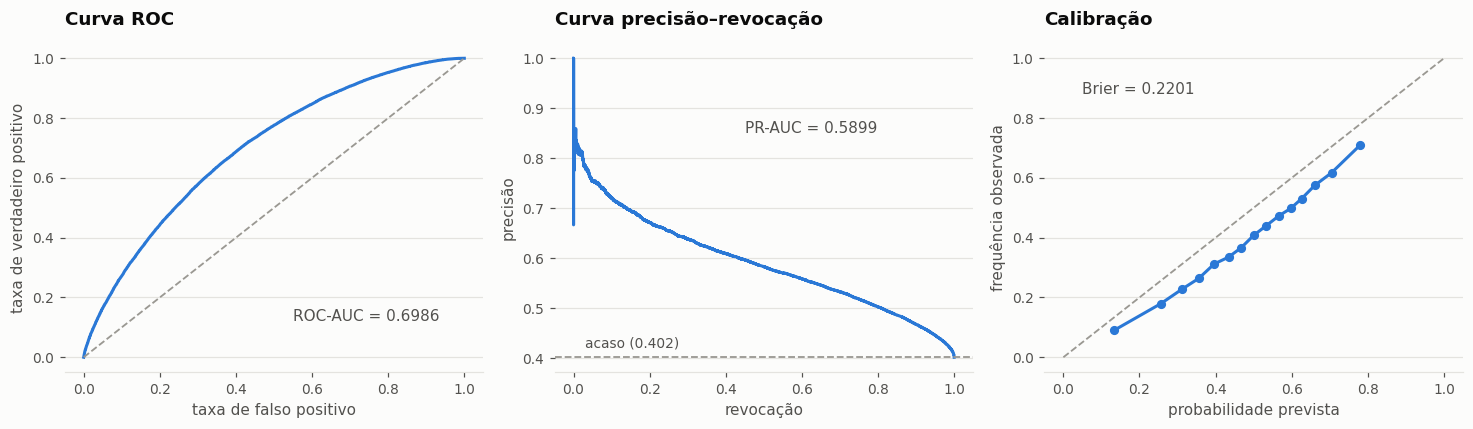

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13.5, 4))

fpr, tpr, _ = roc_curve(y_te, proba)
ax1.plot(fpr, tpr, color=AZUL)
ax1.plot([0, 1], [0, 1], color=NEUTRO, linestyle="--", linewidth=1.2)
ax1.text(0.55, 0.12, f"ROC-AUC = {roc_auc:.4f}", color=TINTA_SEC, fontsize=10)
ax1.set_title("Curva ROC"); ax1.set_xlabel("taxa de falso positivo"); ax1.set_ylabel("taxa de verdadeiro positivo")
limpa_eixos(ax1)

precisao, revocacao, _ = precision_recall_curve(y_te, proba)
prevalencia = y_te.mean()
ax2.plot(revocacao, precisao, color=AZUL)
ax2.axhline(prevalencia, color=NEUTRO, linestyle="--", linewidth=1.2)
ax2.text(0.03, prevalencia + 0.02, f"acaso ({prevalencia:.3f})", color=TINTA_SEC, fontsize=9)
ax2.text(0.45, 0.85, f"PR-AUC = {pr_auc:.4f}", color=TINTA_SEC, fontsize=10)
ax2.set_title("Curva precisão–revocação"); ax2.set_xlabel("revocação"); ax2.set_ylabel("precisão")
limpa_eixos(ax2)

prob_real, prob_prev = calibration_curve(y_te, proba, n_bins=15, strategy="quantile")
ax3.plot(prob_prev, prob_real, color=AZUL, marker="o", markersize=5)
ax3.plot([0, 1], [0, 1], color=NEUTRO, linestyle="--", linewidth=1.2)
ax3.set_title("Calibração"); ax3.set_xlabel("probabilidade prevista"); ax3.set_ylabel("frequência observada")
ax3.text(0.05, 0.88, f"Brier = {registrado['brier']:.4f}", color=TINTA_SEC, fontsize=10)
limpa_eixos(ax3)

fig.tight_layout()
salva(fig, "modelo_curvas.png")
plt.show()

A curva de calibração é o gráfico mais importante desta página. Ela mostra que a
probabilidade devolvida pelo modelo **pode ser lida como probabilidade**: entre os alunos a
que o modelo atribui 30% de risco, aproximadamente 30% de fato não se alfabetizam. Sem isso,
um ranking de priorização não teria significado — só ordenação.

### 4.2 Limiar de decisão

corte padrão de 0,5      F1 = 0.5982  | recall = 0.6710
corte ótimo de 0.387     F1 = 0.6190


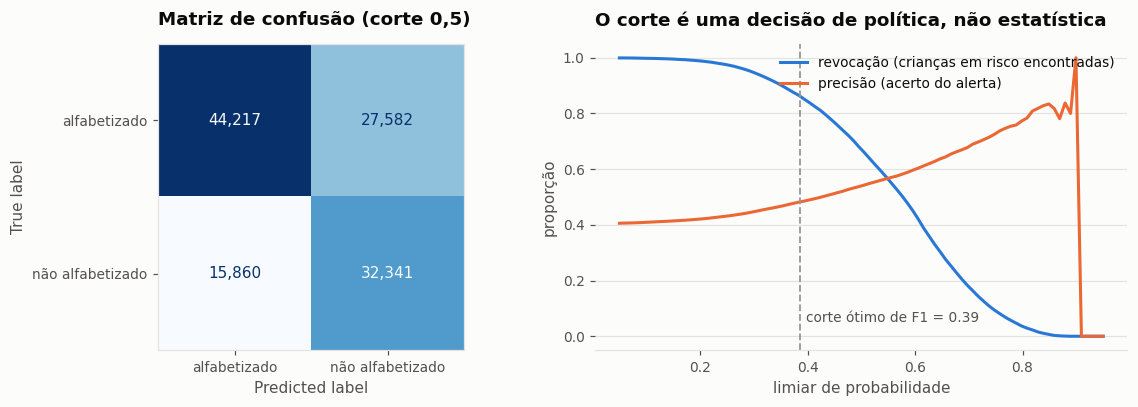

In [8]:
limiar = registrado["limiar_otimo_f1"]
print(f"corte padrão de 0,5      F1 = {registrado['f1']:.4f}  | recall = {registrado['recall_nao_alfabetizado']:.4f}")
print(f"corte ótimo de {limiar:.3f}     F1 = {registrado['f1_no_limiar_otimo']:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ConfusionMatrixDisplay(np.array(metricas["matriz_confusao"]),
                       display_labels=["alfabetizado", "não alfabetizado"]).plot(
    ax=ax1, cmap="Blues", colorbar=False, values_format=",")
ax1.set_title("Matriz de confusão (corte 0,5)")
ax1.grid(False)

cortes = np.linspace(0.05, 0.95, 90)
recalls = [( (proba >= c) & (y_te == 1) ).sum() / (y_te == 1).sum() for c in cortes]
precisoes = [((proba >= c) & (y_te == 1)).sum() / max(1, (proba >= c).sum()) for c in cortes]
ax2.plot(cortes, recalls, color=AZUL, label="revocação (crianças em risco encontradas)")
ax2.plot(cortes, precisoes, color=LARANJA, label="precisão (acerto do alerta)")
ax2.axvline(limiar, color=NEUTRO, linestyle="--", linewidth=1.2)
ax2.text(limiar + 0.01, 0.05, f"corte ótimo de F1 = {limiar:.2f}", color=TINTA_SEC, fontsize=9)
ax2.set_title("O corte é uma decisão de política, não estatística")
ax2.set_xlabel("limiar de probabilidade"); ax2.set_ylabel("proporção")
ax2.legend(loc="upper right")
limpa_eixos(ax2)

fig.tight_layout()
salva(fig, "modelo_limiar.png")
plt.show()

O corte não é uma escolha técnica: define quantas crianças entram no programa de reforço.
Um limiar baixo encontra quase todas as crianças em risco e desperdiça recursos com falsos
alertas; um limiar alto economiza e deixa crianças para trás. O gráfico entrega essa
fronteira ao gestor em vez de esconder a decisão atrás de um 0,5 arbitrário.

### 4.3 Generalização geográfica

O holdout aleatório mede "alunos novos numa rede que já conheço". O holdout **agrupado por
município** — nenhum município aparece nos dois lados — mede "um município sem histórico".
A diferença entre os dois é a medida honesta da dependência do histórico local.

In [9]:
comp = pd.DataFrame({
    "holdout aleatório": metricas["holdout_aleatorio"],
    "holdout por município": metricas["holdout_por_municipio"],
}).T[["roc_auc", "pr_auc", "f1", "recall_nao_alfabetizado", "brier", "prevalencia", "n"]]
comp.columns = ["ROC-AUC", "PR-AUC", "F1", "recall", "Brier", "prevalência", "n"]
display(comp.round(4))

queda = 100 * (1 - comp.loc["holdout por município", "PR-AUC"] / comp.loc["holdout aleatório", "PR-AUC"])
print(f"queda de PR-AUC ao prever um municipio sem historico: {queda:+.1f}%")

,ROC-AUC,PR-AUC,F1,recall,Brier,prevalência,n
holdout aleatório,0.6986,0.5899,0.5982,0.6710,0.2201,0.4017,120000.0
holdout por município,0.6698,0.5456,0.5567,0.6007,0.2347,0.3912,129203.0


queda de PR-AUC ao prever um municipio sem historico: +7.5%


## 5. O teste anti-vazamento

A prova por contradição: se `proficiencia` for reintroduzida, o modelo deve ficar perfeito —
e um modelo perfeito, aqui, é a evidência de que a variável não podia estar lá.

In [10]:
vazado = metricas["teste_anti_leakage_com_proficiencia"]
prova = pd.DataFrame({
    "modelo de produção (sem proficiência)": metricas["holdout_aleatorio"],
    "com proficiência reintroduzida": vazado,
}).T[["roc_auc", "pr_auc", "f1", "recall_nao_alfabetizado", "brier"]]
prova.columns = ["ROC-AUC", "PR-AUC", "F1", "recall", "Brier"]
display(prova.round(4))

print(f"\nROC-AUC com proficiencia: {vazado['roc_auc']:.6f}")
print("Um classificador perfeito nao aprendeu nada sobre alfabetizacao — ele apenas")
print("redescobriu o limiar de 743 pontos que ja define o alvo.")

,ROC-AUC,PR-AUC,F1,recall,Brier
modelo de produção (sem proficiência),0.6986,0.5899,0.5982,0.6710,0.2201
com proficiência reintroduzida,1.0000,1.0000,0.9980,0.9977,0.0010



ROC-AUC com proficiencia: 0.999993
Um classificador perfeito nao aprendeu nada sobre alfabetizacao — ele apenas
redescobriu o limiar de 743 pontos que ja define o alvo.


Esse é exatamente o modelo que um projeto descuidado entregaria: métricas impecáveis,
apresentação convincente e **zero** utilidade, porque a variável só existe depois que a
avaliação aconteceu — quando já não há o que prevenir.

## 6. Interpretabilidade

Dois olhares complementares. A **permutation importance** mede o custo real: quanto o PR-AUC
cai quando a variável é embaralhada no conjunto de teste. Os **valores SHAP** decompõem cada
predição individual, mostrando direção além de magnitude.

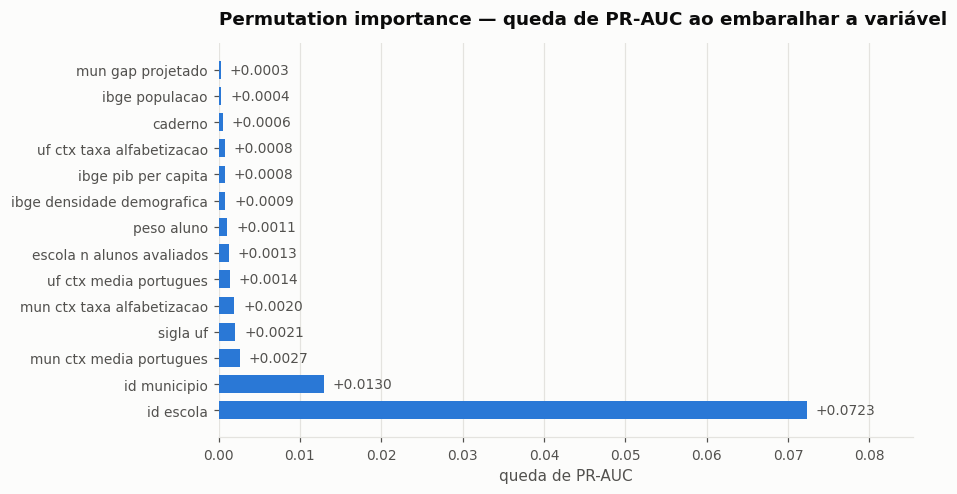

In [11]:
imp = pd.read_csv(REPORTS_DIR / "importancia_permutacao_aluno.csv").head(14)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ordenado = imp.sort_values("queda_pr_auc")
barras_horizontais(ax, [f.replace("_", " ") for f in ordenado["feature"]],
                   list(ordenado["queda_pr_auc"]), formato="{:+.4f}")
ax.set_title("Permutation importance — queda de PR-AUC ao embaralhar a variável")
ax.set_xlabel("queda de PR-AUC")
fig.tight_layout()
salva(fig, "modelo_importancia_permutacao.png")
plt.show()

In [12]:
shap_rank = pd.read_csv(REPORTS_DIR / "importancia_shap_aluno.csv").head(15)
display(shap_rank.round(5))

,feature,shap_medio_abs
0,alta_card__id_escola,0.40838
1,alta_card__id_municipio,0.16628
2,num__mun_ctx_media_portugues,0.06959
3,num__peso_aluno,0.06820
4,num__mun_gap_projetado,0.03399
5,num__mun_ctx_taxa_alfabetizacao,0.03163
6,num__uf_ctx_media_portugues,0.02336
7,num__escola_n_alunos_avaliados,0.02169
8,cat__sigla_uf_RS,0.02051
9,num__uf_ctx_taxa_alfabetizacao,0.01487


### Beeswarm: direção e magnitude por aluno

Cada ponto é um aluno. A posição horizontal é a contribuição para o risco; a cor é o valor
da variável. É o gráfico que responde "alto ou baixo, em que direção empurra".

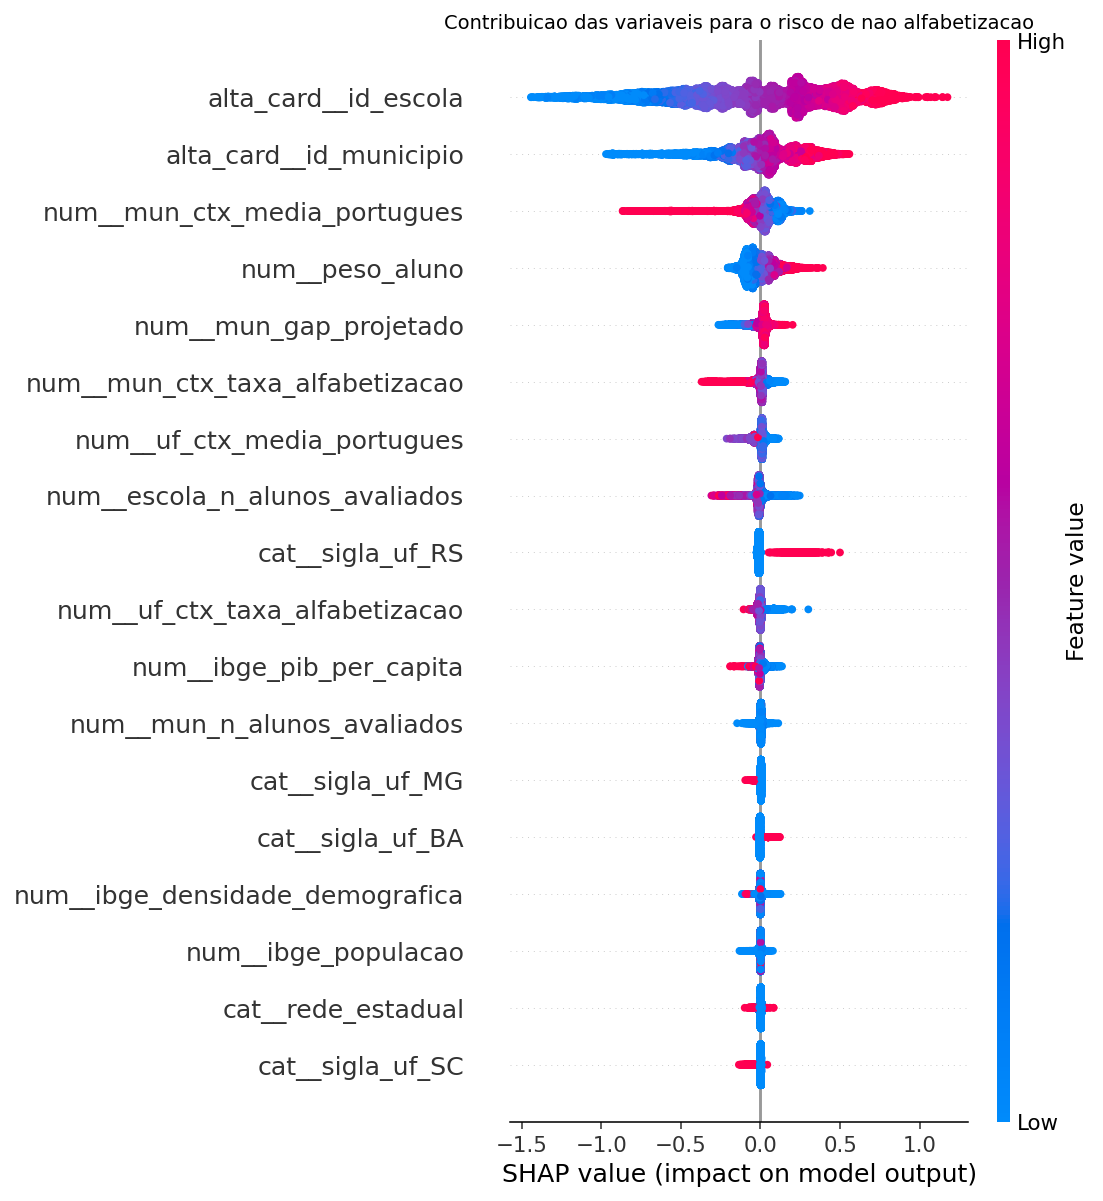

In [13]:
from IPython.display import Image, display as mostra
mostra(Image(filename="../reports/images/shap_beeswarm_aluno.png"))

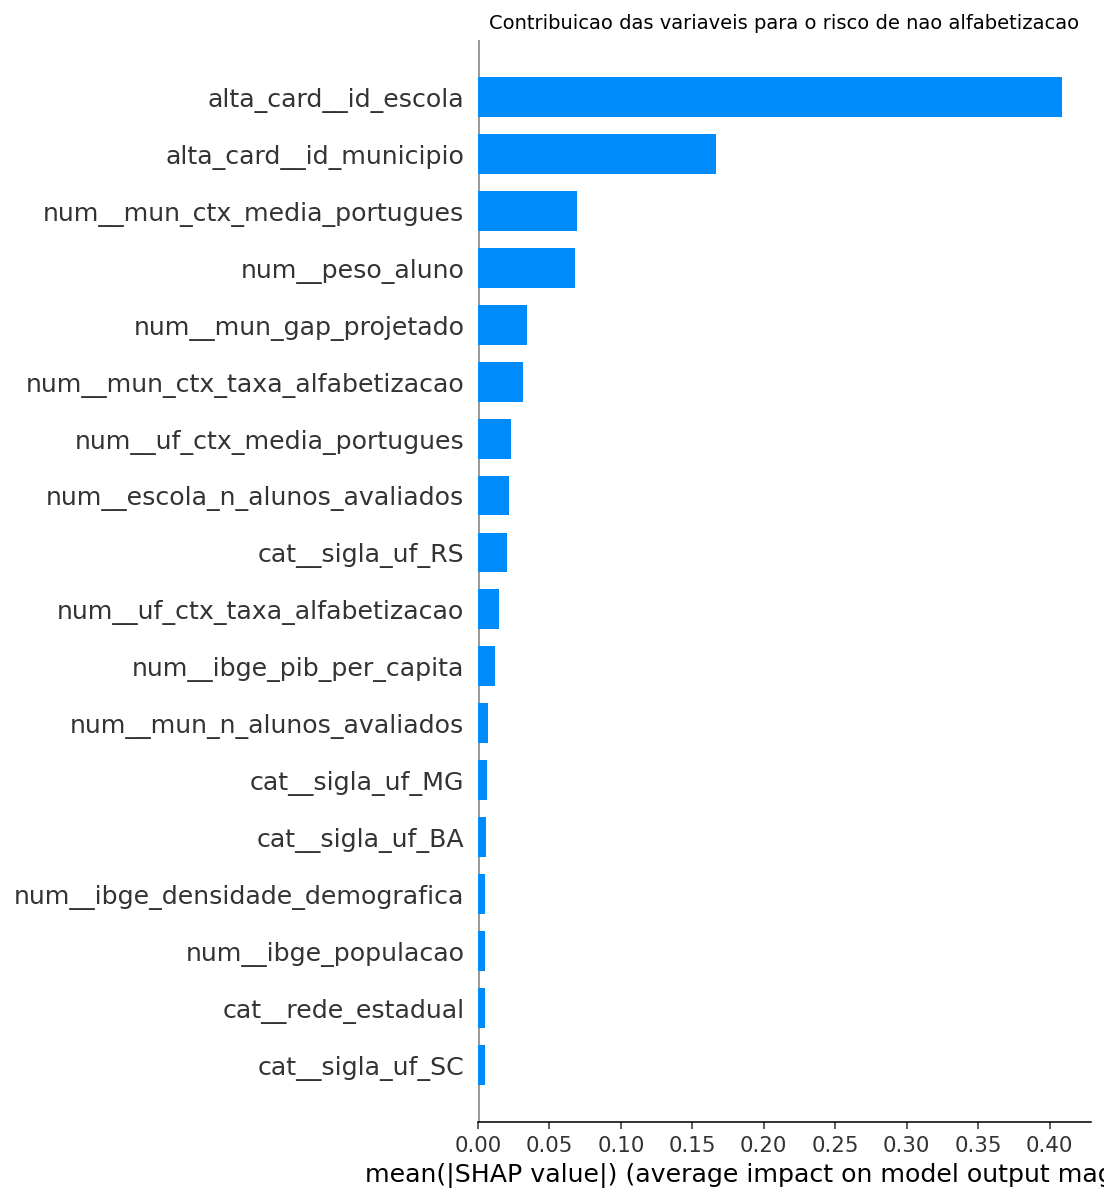

In [14]:
mostra(Image(filename="../reports/images/shap_bar_aluno.png"))

## 7. Leitura dos resultados

**O sinal é hierárquico, e a escola está no topo.** A ordem das importâncias é nítida:
`id_escola` (+0,069 de queda de PR-AUC) pesa cinco vezes mais que `id_municipio` (+0,014),
que por sua vez pesa quase dez vezes mais que `sigla_uf` (+0,002). O contexto municipal
agregado — taxa e média de português de 2023 — entra depois. Quanto mais granular a unidade
territorial, mais ela explica.

Isso não é vazamento: o `TargetEncoder` de `id_escola` é ajustado por cross-fitting, então a
codificação de cada aluno vem de outras escolas... mais precisamente, de outros alunos da
mesma escola em folds distintos. O que ele captura é o **efeito-escola**: a variação de
desempenho entre escolas do mesmo município é maior que a variação entre municípios.

E é exatamente isso que explica a queda no holdout agrupado. Quando um município inteiro
fica fora do treino, `id_escola` e `id_municipio` são categorias inéditas e o encoder as
manda para o prior global — o modelo perde sua variável mais forte e cai de 0,592 para
0,537 de PR-AUC. A diferença entre os dois holdouts **é** o efeito-escola, medido.

**Por que o teto é baixo mesmo assim.** Um PR-AUC de 0,59 contra uma prevalência de 0,40 é
ganho real mas modesto. A razão é estrutural: os microdados públicos do Indicador Criança
Alfabetizada **não trazem atributos individuais**. Não há renda familiar, frequência,
escolaridade dos pais, trajetória, defasagem idade-série ou infraestrutura da escola. O
modelo sabe *em que escola* a criança estuda, não *quem* ela é.

Duas crianças na mesma escola, mesma rede, mesmo caderno recebem a mesma predição — mas uma
se alfabetiza e a outra não. Nenhum algoritmo resolve isso; só dado novo resolve.

**Por isso a entrega útil é a priorização, não o alerta individual.** O modelo não deve
gerar uma lista de crianças a acompanhar — não tem resolução para isso. Ele deve ordenar
**escolas, redes e municípios** por risco agregado, onde os erros individuais se cancelam e
o sinal territorial que ele de fato captura fica visível. É o que o notebook 03 constrói.

> Nota sobre `peso_aluno`: ele aparece em 4º lugar (+0,003), acima de `sigla_uf`. Não é uma
> característica da criança — é o peso amostral do desenho da avaliação, que varia por
> estrato. Funciona como proxy fraco de contexto, não como informação individual.

In [15]:
resumo = {
    "modelo": metricas["modelo_escolhido"],
    "features": len(metricas["features"]),
    "treino": metricas["n_treino"],
    "teste": metricas["n_teste"],
    "PR-AUC (holdout aleatório)": round(metricas["holdout_aleatorio"]["pr_auc"], 4),
    "PR-AUC (município novo)": round(metricas["holdout_por_municipio"]["pr_auc"], 4),
    "PR-AUC do acaso": round(metricas["holdout_aleatorio"]["prevalencia"], 4),
    "ROC-AUC": round(metricas["holdout_aleatorio"]["roc_auc"], 4),
    "recall da classe em risco": round(metricas["holdout_aleatorio"]["recall_nao_alfabetizado"], 4),
    "Brier": round(metricas["holdout_aleatorio"]["brier"], 4),
    "ROC-AUC no teste anti-vazamento": round(metricas["teste_anti_leakage_com_proficiencia"]["roc_auc"], 4),
    "semente": metricas["seed"],
}
display(pd.Series(resumo).to_frame("valor"))

,valor
modelo,hist_gradient_boosting
features,22
treino,480000
teste,120000
PR-AUC (holdout aleatório),0.5899
PR-AUC (município novo),0.5456
PR-AUC do acaso,0.4017
ROC-AUC,0.6986
recall da classe em risco,0.671
Brier,0.2201
